In [ ]:

!pip install nltk scikit-learn rank_bm25 tqdm

import nltk
nltk.download('punkt')
nltk.download('stopwords')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
import re
import numpy as np
from tqdm import tqdm
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from rank_bm25 import BM25Okapi


In [5]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [10]:
import os

cisi_path = "/content/drive/MyDrive/Colab Notebooks/"
print(os.listdir(cisi_path))


['Untitled14.ipynb', 'cisi.que', 'cisi.rel', 'cisi.ALL', 'Untitled0.ipynb', 'Week7.ipynb', 'Untitled1.ipynb', 'Untitled2.ipynb', 'Untitled3.ipynb', 'Untitled4.ipynb', 'Untitled5.ipynb', 'Untitled6.ipynb', 'Untitled7.ipynb', 'Untitled8.ipynb', 'Untitled9.ipynb', 'Untitled10.ipynb', 'Untitled11.ipynb', 'Week5lab.ipynb', 'Untitled12.ipynb', 'Untitled13.ipynb', 'W01L01_Boolean_Retrieval_System.ipynb']


In [11]:
from google.colab import drive
drive.mount('/content/drive')

cisi_path = "/content/drive/MyDrive/Colab Notebooks/"

cisi_all_path = cisi_path + "cisi.ALL"
cisi_rel_path = cisi_path + "cisi.rel"
cisi_qry_path = cisi_path + "cisi.que"

with open(cisi_all_path, "r", errors="ignore") as f:
    cisi_all = f.read()

with open(cisi_rel_path, "r", errors="ignore") as f:
    cisi_rel = f.read()

with open(cisi_qry_path, "r", errors="ignore") as f:
    cisi_qry = f.read()

print("CISI files loaded successfully!")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CISI files loaded successfully!


In [13]:
doc_pattern = re.compile(r"\.I\s+(\d+)\s+\.T(.*?)\.A(.*?)\.W(.*?)\.X", re.DOTALL)
documents = {}

for match in doc_pattern.finditer(cisi_all):
    doc_id = int(match.group(1))
    title = match.group(2).strip()
    abstract = match.group(4).strip()
    documents[doc_id] = title + " " + abstract

print("Total documents parsed:", len(documents))


Total documents parsed: 1460


In [14]:
query_pattern = re.compile(r"\.I\s+(\d+)\s+\.W(.*?)\n(?=\.I|\Z)", re.DOTALL)
queries = {}

for match in query_pattern.finditer(cisi_qry):
    q_id = int(match.group(1))
    q_text = match.group(2).strip()
    queries[q_id] = q_text

print("Total queries parsed:", len(queries))


Total queries parsed: 57


In [15]:
relevance = {}

for line in cisi_rel.splitlines():
    parts = line.split()
    if len(parts) >= 2:
        q_id = int(parts[0])
        d_id = int(parts[1])
        relevance.setdefault(q_id, []).append(d_id)

print("Relevance judgments loaded:", len(relevance))


Relevance judgments loaded: 76


In [16]:
corpus = [documents[i] for i in sorted(documents.keys())]

vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = vectorizer.fit_transform(corpus)

print("TF-IDF matrix shape:", tfidf_matrix.shape)


TF-IDF matrix shape: (1460, 9726)


In [17]:
query_texts = [queries[q] for q in sorted(queries.keys())]
query_vectors = vectorizer.transform(query_texts)

print("Query vector shape:", query_vectors.shape)


Query vector shape: (57, 9726)


In [19]:
from sklearn.metrics.pairwise import cosine_similarity


In [20]:
similarity_scores = cosine_similarity(query_vectors, tfidf_matrix)

def get_top_k(sim_scores, k=10):
    return np.argsort(sim_scores)[::-1][:k] + 1


In [21]:
q_id = 1
top_docs = get_top_k(similarity_scores[q_id-1])

print(f"Top 10 documents for Query {q_id}:")
print(top_docs)


Top 10 documents for Query 1:
[ 722  429 1281  589  813 1299  650  711  510  219]


In [22]:
def precision_at_k(q_id, retrieved_docs, k=10):
    relevant = set(relevance.get(q_id, []))
    retrieved_top_k = set(retrieved_docs[:k])
    return len(retrieved_top_k & relevant) / k

precisions = []
for i, q_id in enumerate(sorted(queries.keys())):
    retrieved = get_top_k(similarity_scores[i], 10)
    precisions.append(precision_at_k(q_id, retrieved, 10))

print("Average Precision@10:", np.mean(precisions))


Average Precision@10: 0.2719298245614035


In [23]:
def precision_at_k(retrieved_docs, relevant_docs, k):
    retrieved_k = retrieved_docs[:k]
    relevant_found = len(set(retrieved_k) & set(relevant_docs))
    return relevant_found / k

def recall_at_k(retrieved_docs, relevant_docs, k):
    if len(relevant_docs) == 0:
        return 0
    retrieved_k = retrieved_docs[:k]
    relevant_found = len(set(retrieved_k) & set(relevant_docs))
    return relevant_found / len(relevant_docs)


In [24]:
def dcg(retrieved_docs, relevant_docs, k):
    dcg_val = 0.0
    for i, doc in enumerate(retrieved_docs[:k]):
        if doc in relevant_docs:
            dcg_val += 1 / np.log2(i + 2)
    return dcg_val

def ndcg(retrieved_docs, relevant_docs, k):
    ideal = dcg(list(relevant_docs), relevant_docs, k)
    if ideal == 0:
        return 0
    return dcg(retrieved_docs, relevant_docs, k) / ideal


In [27]:
query_ids = sorted(queries.keys())
k = 10

precisions = []
recalls = []
ndcgs = []
average_precisions = []

for i, qid in enumerate(query_ids):
    rel_docs = relevance.get(qid, [])

    sim_scores = similarity_scores[i]
    ranked = np.argsort(sim_scores)[::-1] + 1

    precisions.append(precision_at_k(ranked, rel_docs, k))
    recalls.append(recall_at_k(ranked, rel_docs, k))
    ndcgs.append(ndcg(ranked, rel_docs, k))

    retrieved_k = ranked[:k]
    hits = 0
    score = 0.0
    for j, doc in enumerate(retrieved_k):
        if doc in rel_docs:
            hits += 1
            score += hits / (j + 1)
    average_precisions.append(score / len(rel_docs) if len(rel_docs) > 0 else 0)

print("TF-IDF Evaluation:")
print("Precision@10:", np.mean(precisions))
print("Recall@10:", np.mean(recalls))
print("nDCG@10:", np.mean(ndcgs))
print("MAP@10:", np.mean(average_precisions))


TF-IDF Evaluation:
Precision@10: 0.2719298245614035
Recall@10: 0.0784726011697524
nDCG@10: 0.28969659765872774
MAP@10: 0.05055605911435895


In [29]:
!pip install rank_bm25

from rank_bm25 import BM25Okapi
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import re

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def preprocess(text):
    text = text.lower()
    tokens = re.findall(r"[a-z0-9]+", text)
    tokens = [t for t in tokens if t not in stop_words]
    tokens = [stemmer.stem(t) for t in tokens]
    return tokens

bm25_corpus = [preprocess(doc) for doc in documents.values()]

bm25 = BM25Okapi(bm25_corpus)

print("BM25 model is ready!")


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


BM25 model is ready!


In [30]:
k = 10
precisions_bm25 = []
recalls_bm25 = []
ndcgs_bm25 = []
average_precisions_bm25 = []

query_ids = sorted(queries.keys())

for i, qid in enumerate(query_ids):
    rel_docs = relevance.get(qid, [])
    query_tokens = preprocess(queries[qid])

    scores = bm25.get_scores(query_tokens)
    ranked = np.argsort(scores)[::-1] + 1

    # Metrics
    precisions_bm25.append(precision_at_k(ranked, rel_docs, k))
    recalls_bm25.append(recall_at_k(ranked, rel_docs, k))
    ndcgs_bm25.append(ndcg(ranked, rel_docs, k))

    # AP@10
    retrieved_k = ranked[:k]
    hits = 0
    score = 0.0
    for j, doc in enumerate(retrieved_k):
        if doc in rel_docs:
            hits += 1
            score += hits / (j + 1)
    average_precisions_bm25.append(score / len(rel_docs) if len(rel_docs) > 0 else 0)

print("BM25 Evaluation:")
print("Precision@10:", np.mean(precisions_bm25))
print("Recall@10:", np.mean(recalls_bm25))
print("nDCG@10:", np.mean(ndcgs_bm25))
print("MAP@10:", np.mean(average_precisions_bm25))


BM25 Evaluation:
Precision@10: 0.3192982456140351
Recall@10: 0.1047603836972521
nDCG@10: 0.3357493270739982
MAP@10: 0.05801340628249605


        Precision@10  Recall@10   nDCG@10    MAP@10
TF-IDF      0.271930   0.078473  0.289697  0.050556
BM25        0.319298   0.104760  0.335749  0.058013


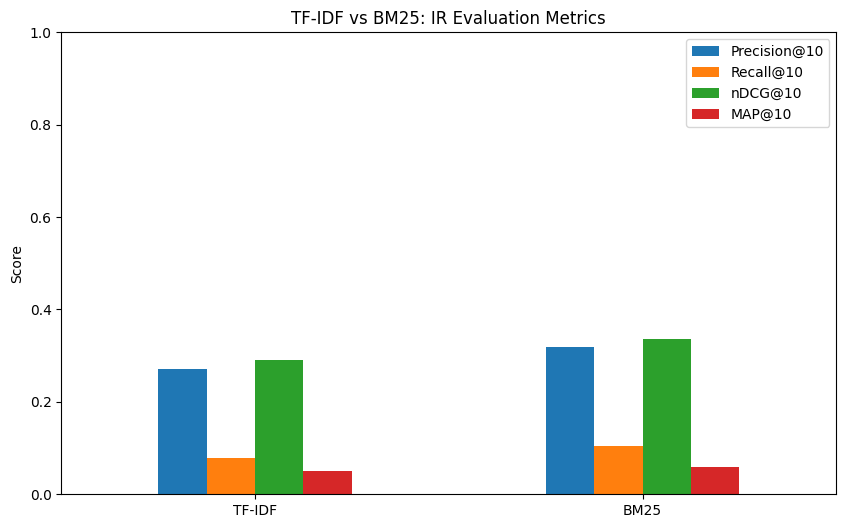

In [31]:
import pandas as pd
import matplotlib.pyplot as plt


tfidf_metrics = {
    "Precision@10": np.mean(precisions),
    "Recall@10": np.mean(recalls),
    "nDCG@10": np.mean(ndcgs),
    "MAP@10": np.mean(average_precisions)
}


bm25_metrics = {
    "Precision@10": np.mean(precisions_bm25),
    "Recall@10": np.mean(recalls_bm25),
    "nDCG@10": np.mean(ndcgs_bm25),
    "MAP@10": np.mean(average_precisions_bm25)
}


comparison_df = pd.DataFrame([tfidf_metrics, bm25_metrics], index=["TF-IDF", "BM25"])
print(comparison_df)


comparison_df.plot(kind="bar", figsize=(10,6))
plt.title("TF-IDF vs BM25: IR Evaluation Metrics")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0,1)
plt.legend(loc='upper right')
plt.show()
